In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel("../../datasets/multiple_regression_dataset.xlsx")

dataset.head(5)

,Age,Experience,Salary
0,22,0,18000
1,25,2,25000
2,28,4,32000
3,30,6,40000
4,35,10,55000


In [14]:
dataset.isnull().sum()

Age           0
Experience    0
Salary        0
dtype: int64

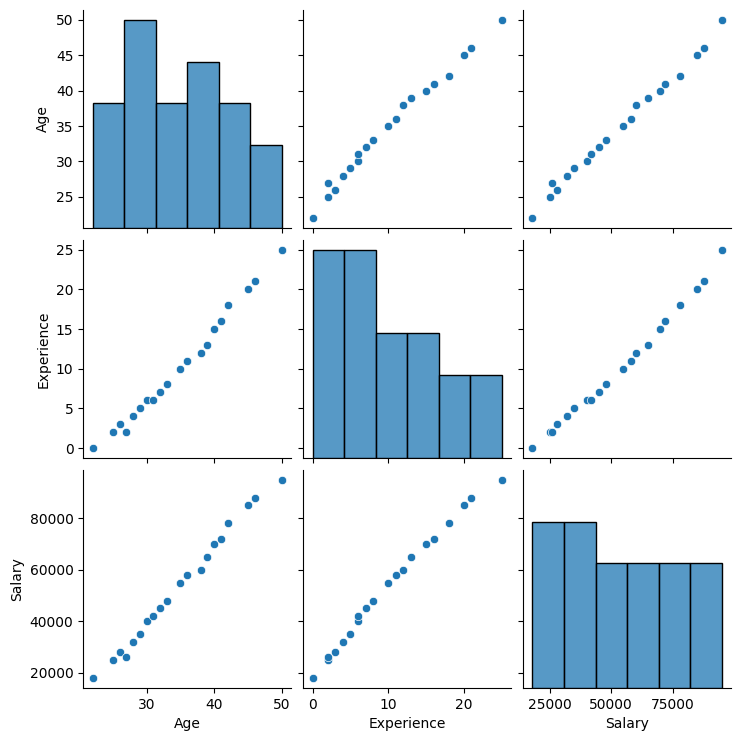

In [15]:
sns.pairplot(data=dataset)
plt.show()

In [16]:
x = dataset.iloc[:,:-1]
y = dataset["Experience"]

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [20]:
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [21]:
dt.score(x_test, y_test)*100

92.6829268292683

In [22]:
dt.score(x_train, y_train)*100

100.0

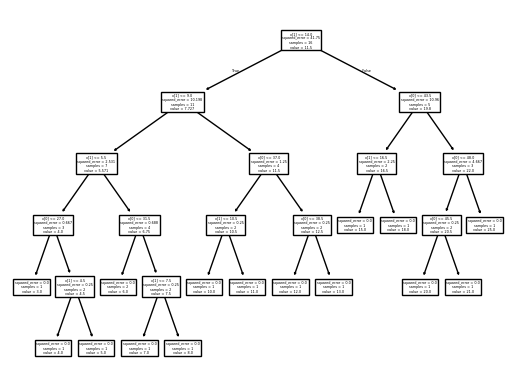

In [23]:
plot_tree(dt)
plt.show()

**निर्णय वृक्ष रिग्रेशन** (Decision Tree Regression) एक मशीन लर्निंग पद्धत आहे जी सतत मूल्यांचा (continuous values) अंदाज लावण्यासाठी वापरली जाते. या पद्धतीमध्ये, डेटा एक वृक्षाच्या (tree) रूपात विभागला जातो, आणि प्रत्येक नोडच्या आधारावर योग्य निर्णय घेतला जातो.

### **मुख्य तत्वे:**

* **रूट नोड (Root Node):** प्रारंभ बिंदू.
* **आंतरिक नोड्स (Internal Nodes):** निर्णय घेणारे नोड्स.
* **पत्ता (Leaf Node):** अंतिम निर्णय.

### **कार्यप्रणाली:**

* डेटा विभाजन विविध फीचर्सच्या आधारे केले जाते.
* प्रत्येक नोड विभाजनाच्या निकषाने डेटा विभागतो.
* प्रत्येक **leaf node** मध्ये सरासरी वापरून मूल्य प्रेडिक्ट केले जाते.

### **फायदे:**

* **सोपे समजणे** (Interpretability).
* **नॉन-लिनियर रिलेशन** हाताळू शकतो.

### **तोटे:**

* **ओव्हरफिटिंग** होऊ शकते.
* **प्रशिक्षण वेळ** जास्त लागू शकतो.

### **उदाहरण:**

घराच्या किंमतीचा अंदाज लावण्यासाठी **वय**, **उंची**, **काळ** इत्यादी फीचर्स वापरून निर्णय घेतला जातो.

**निष्कर्ष:** निर्णय वृक्ष रिग्रेशन डेटा प्रेडिक्शनसाठी प्रभावी आहे, पण ओव्हरफिटिंग टाळण्यासाठी योग्य ट्यूनिंग आवश्यक आहे.
